Wrapping my head around the [neural tangent kernel](https://arxiv.org/abs/1806.07572) (and [Novak et al](https://arxiv.org/abs/2206.08720)), using https://docs.pytorch.org/tutorials/intermediate/neural_tangent_kernels.html as a starting point.

In [1]:
import torch
import torch.nn as nn
from torch.func import functional_call, vmap, vjp, jvp, jacrev
import numpy as np
import matplotlib.pyplot as plt

if torch.accelerator.is_available() and torch.accelerator.device_count() > 0:
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")


class NN(nn.Module):
    def __init__(self, insize, width, outsize):
        super(NN, self).__init__()
        self.l1 = nn.Linear(insize, width)
        self.l2 = nn.Linear(width, width)
        self.l3 = nn.Linear(width, outsize)
        
    def forward(self, x):
        x = self.l1(x)
        x = x.relu()
        x = self.l2(x)
        x = x.relu()
        x = self.l3(x)
        return x

In [2]:
X_train = torch.randn(5, 1, device=device)
#X_test = torch.randn(5, 1, device=device)
X_test = torch.linspace(X_train.min() - 0.5, X_train.max() + 0.5, 300, device=device).reshape(-1, 1)


y_train = torch.randn(5, 1, device=device)
#y_test = torch.randn(5, 1, device=device)

In [3]:
net = NN(1, 100, 1).to(device)

# Detaching the parameters because we won't be calling Tensor.backward().
params = {k: v.detach() for k, v in net.named_parameters()}

def fnet_single(params, x):
    return functional_call(net, params, (x.unsqueeze(0),)).squeeze(0)

In [6]:
def empirical_ntk_ntk_vps(func, params, x1, x2, compute='full'):
    def get_ntk(x1, x2):
        def func_x1(params):
            return func(params, x1)

        def func_x2(params):
            return func(params, x2)

        output, vjp_fn = vjp(func_x1, params)

        def get_ntk_slice(vec):
            # This computes ``vec @ J(x2).T``
            # `vec` is some unit vector (a single slice of the Identity matrix)
            vjps = vjp_fn(vec)
            # This computes ``J(X1) @ vjps``
            _, jvps = jvp(func_x2, (params,), vjps)
            return jvps

        # Here's our identity matrix
        basis = torch.eye(output.numel(), dtype=output.dtype, device=output.device).view(output.numel(), -1)
        return vmap(get_ntk_slice)(basis)

    # ``get_ntk(x1, x2)`` computes the NTK for a single data point x1, x2
    # Since the x1, x2 inputs to ``empirical_ntk_ntk_vps`` are batched,
    # we actually wish to compute the NTK between every pair of data points
    # between {x1} and {x2}. That's what the ``vmaps`` here do.
    result = vmap(vmap(get_ntk, (None, 0)), (0, None))(x1, x2)

    if compute == 'full':
        return result
    if compute == 'trace':
        return torch.einsum('NMKK->NM', result)
    if compute == 'diagonal':
        return torch.einsum('NMKK->NMK', result)

In [7]:
K_train = empirical_ntk_ntk_vps(fnet_single, params, X_train, X_train)[:,:,0,0].cpu().numpy()  # (n, n)
K_cross = empirical_ntk_ntk_vps(fnet_single, params, X_test, X_train)[:,:,0,0].cpu().numpy()   # (m, n)
K_test  = empirical_ntk_ntk_vps(fnet_single, params, X_test, X_test)[:,:,0,0].cpu().numpy()    # (m, m)

noise = 1e-4  # ridge for numerical stability (or actual observation noise σ²)

K_reg = K_train + noise * np.eye(len(X_train))
alpha = np.linalg.solve(K_reg, y_train.cpu().numpy())          # (K + σ²I)⁻¹ y

# Posterior mean and variance
mu_post  = K_cross @ alpha                        # shape (m,)
v        = np.linalg.solve(K_reg, K_cross.T)      # (n, m)
var_post = np.diag(K_test - K_cross @ v)          # shape (m,)

/home/scott/repos/nn-ag/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [8]:
mu_post

array([[ 0.91764422],
       [ 0.90236027],
       [ 0.88709252],
       [ 0.87179309],
       [ 0.85653529],
       [ 0.84123543],
       [ 0.82595774],
       [ 0.81067646],
       [ 0.79539904],
       [ 0.78011988],
       [ 0.7648311 ],
       [ 0.74956177],
       [ 0.73426192],
       [ 0.71898488],
       [ 0.70352229],
       [ 0.68743965],
       [ 0.67135822],
       [ 0.65527439],
       [ 0.63919251],
       [ 0.62312172],
       [ 0.6072026 ],
       [ 0.59155187],
       [ 0.57590134],
       [ 0.56025103],
       [ 0.54459079],
       [ 0.52893466],
       [ 0.51247166],
       [ 0.49600885],
       [ 0.47954538],
       [ 0.46308213],
       [ 0.44660423],
       [ 0.4301374 ],
       [ 0.41367975],
       [ 0.39720353],
       [ 0.3807443 ],
       [ 0.36427737],
       [ 0.34781983],
       [ 0.33135197],
       [ 0.31488459],
       [ 0.29841733],
       [ 0.29691307],
       [ 0.28010208],
       [ 0.26332306],
       [ 0.24648513],
       [ 0.22724847],
       [ 0

In [9]:
alpha.shape

(5, 1)

In [10]:
def plot_ntk_gp(X_train, y_train, X_test, mu_post, var_post, n_std=2):
    """
    X_train: (n,) or (n,1)
    y_train: (n,)
    X_test:  (m,) or (m,1) — should be a dense grid for smooth curves
    mu_post: (m,)
    var_post: (m,)  — marginal variances (not std)
    """
    x_tr = X_train.squeeze()
    x_te = X_test.squeeze()
    std  = np.sqrt(np.clip(var_post, 0, None))  # clip for numerical safety

    fig, ax = plt.subplots(figsize=(10, 5))

    # Uncertainty bands (e.g. 1σ and 2σ)
    for k in range(n_std, 0, -1):
        print(x_te.shape)
        print(mu_post.shape)
        ax.fill_between(
            x_te,
            mu_post - k * std,
            mu_post + k * std,
            alpha=0.15 + 0.05 * (n_std - k),
            color="steelblue",
            label=f"${k}\\sigma$"
        )

    # Posterior mean
    ax.plot(x_te, mu_post, color="steelblue", lw=2, label="Posterior mean")

    # Training data
    print(x_tr.shape, y_train.shape)
    ax.scatter(x_tr.cpu(), y_train[:,0].cpu(), color="black", zorder=5, s=40, label="Training data")

    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_title("NTK GP Posterior")
    ax.legend()
    plt.tight_layout()
    plt.show()

torch.Size([300])
(300,)
torch.Size([300])
(300,)
torch.Size([5]) torch.Size([5, 1])


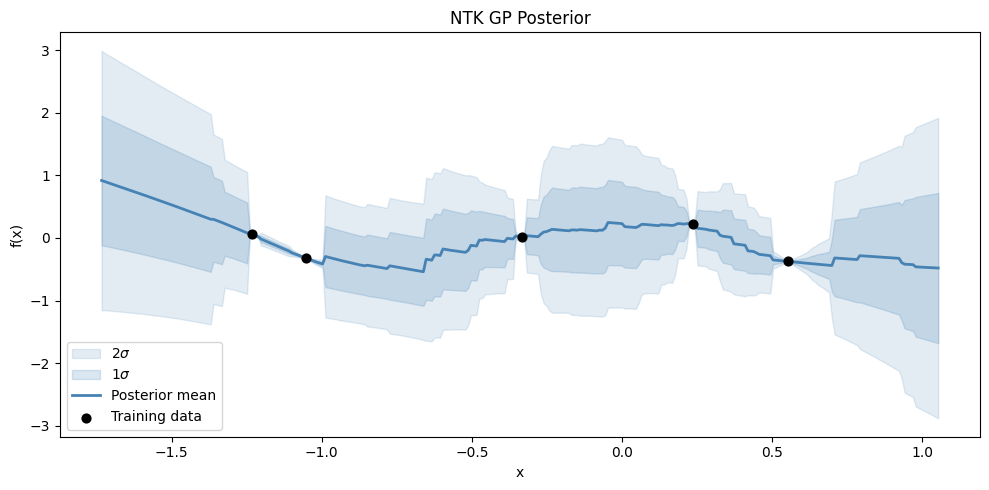

In [14]:
plot_ntk_gp(X_train.cpu(), y_train.cpu(), X_test.cpu(), mu_post[:,0], var_post)